<!-- AI-og-helse: colab-kontrakt v1 -->

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/AI-og-helse/blob/main/uke06-klinisk-praksis/04_fra_modell_til_klinisk_arbeidsflyt.ipynb)

## Colab-kjøring

- **Anbefalt runtime:** CPU
- **Forventet kjøretid:** 15-30 min
- **Datamønster:** `synthetic-or-inline`

**Krav før kjøring:**
- API: ikke nødvendig
- Data: syntetisk klinisk datasett
- GPU: ikke nødvendig

**Felles konvensjon:** Kjør setup-cellen rett under først. I Colab hentes hemmeligheter fra **Secrets** med `userdata.get(...)`; lokalt brukes miljøvariabler eller `.env`.

Kjør cellene ovenfra og ned. Setup-cellen installerer bare ekstra pakker når notebooken åpnes i Colab.


In [1]:
# AI-og-helse: Colab bootstrap v1
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
NOTEBOOK_PACKAGES = []
COLAB_DATA_MODE = 'synthetic-or-inline'


def _has_import(import_name: str) -> bool:
    return importlib.util.find_spec(import_name) is not None


def ensure_packages(packages=NOTEBOOK_PACKAGES):
    """Install only notebook-specific packages when running in Colab."""
    if not IN_COLAB:
        return

    missing = [package for package, import_name in packages if not _has_import(import_name)]
    if missing:
        print("Installerer Colab-pakker:", ", ".join(missing))
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    else:
        print("Alle notebook-spesifikke Colab-pakker er tilgjengelige.")


def get_secret(name: str, *aliases: str):
    """Read secrets from environment/.env locally or Colab Secrets in Colab."""
    for key in (name, *aliases):
        value = os.getenv(key)
        if value:
            os.environ[name] = value
            return value

    if IN_COLAB:
        try:
            from google.colab import userdata
        except Exception:
            userdata = None

        if userdata is not None:
            for key in (name, *aliases):
                try:
                    value = userdata.get(key)
                except Exception:
                    value = None
                if value:
                    os.environ[name] = value
                    return value

    return None


def mount_drive_if_needed():
    """Mount Google Drive explicitly in notebooks that need persistent artifacts."""
    if not IN_COLAB:
        return None
    from google.colab import drive

    drive.mount("/content/drive")
    return Path("/content/drive/MyDrive")


ensure_packages()
print("Miljø:", "Google Colab" if IN_COLAB else "lokalt")
print("Datamønster:", COLAB_DATA_MODE)


Miljø: lokalt
Datamønster: synthetic-or-inline


# 🏥 Fra modell til klinisk arbeidsflyt

I de tre foregående notebookene har vi sett på hvordan en modell lages, hvordan terskler påvirker beslutninger, og hvorfor validering og subgrupper betyr noe. Denne siste notebooken samler trådene: Hva må faktisk være på plass før en modell kan brukes som en del av klinisk arbeidsflyt?

## Bro fra uke 4 og 5

Uke 4 og 5 viste hva moderne modeller, API-er og agentiske systemer kan gjøre i avgrensede demoer. Denne notebooken handler om overgangen fra demo til praksis. Selv et imponerende LLM-svar, en fungerende RAG-prototype eller en agent som velger riktige verktøy, må vurderes som et klinisk system dersom det påvirker dokumentasjon, prioritering, oppfølging eller beslutninger.

## Læringsmål
- beskrive hva som må til før en modell kan brukes i klinisk praksis
- forstå forskjellen mellom en notebook-modell og et system i drift
- identifisere roller, ansvar og behov for menneskelig kontroll
- reflektere over monitorering og oppfølging etter innføring

### 🔧 Miljøoppsett – fungerer både lokalt og i Google Colab

In [2]:
import sys, subprocess, os
import matplotlib.pyplot as plt

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    print("🚀 Kjører i Google Colab")
    if not os.path.exists('AI-og-helse'):
        print("📥 Laster ned kursmateriell...")
        subprocess.check_call(["git", "clone", "https://github.com/arvidl/AI-og-helse.git"])
    if os.path.exists('AI-og-helse'):
        os.chdir('AI-og-helse')
        print(f"📁 Byttet til mappe: {os.getcwd()}")
else:
    print("💻 Kjører i lokalt miljø")

plt.rcParams['figure.figsize'] = (10, 4)
print("✅ Miljø klart")

💻 Kjører i lokalt miljø
✅ Miljø klart


## En modell i en notebook er ikke det samme som et klinisk system

I en notebook kan vi trene, teste og visualisere en modell. Men i klinisk praksis er ikke spørsmålet bare om modellen virker, men hvordan den virker sammen med mennesker, rutiner og ansvarslinjer.

Derfor må vi også vite:

- hvem som skal bruke systemet
- hva brukeren faktisk skal se
- når systemet skal brukes i arbeidsflyten
- hva som skjer hvis modellen er usikker eller utilgjengelig
- hvordan feil oppdages, håndteres og følges opp

En modell blir først klinisk relevant når den passer inn i en reell arbeidsflyt og gir støtte på et tidspunkt der noen faktisk kan handle på den.

Dette gjelder uansett modelltype: logistisk regresjon, bildegjenkjenning, LLM, RAG-system eller agentisk arbeidsflyt. Jo mer systemet kan foreslå, hente, skrive eller handle, desto tydeligere må grensene for menneskelig kontroll, logging, avvikshåndtering og stoppmekanismer være.

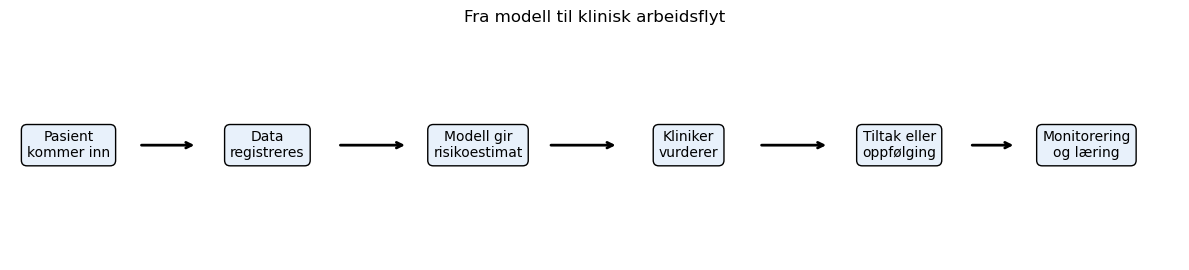

In [3]:
# Enkel visualisering av en AI-støttet klinisk arbeidsflyt

fig, ax = plt.subplots(figsize=(12, 2.8))
ax.axis('off')

steg = [
    'Pasient\nkommer inn',
    'Data\nregistreres',
    'Modell gir\nrisikoestimat',
    'Kliniker\nvurderer',
    'Tiltak eller\noppfølging',
    'Monitorering\nog læring'
]

x_pos = [0.05, 0.22, 0.40, 0.58, 0.76, 0.92]
for x, tekst in zip(x_pos, steg):
    ax.text(x, 0.5, tekst, ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#e8f1fb', edgecolor='black'))

for i in range(len(x_pos) - 1):
    ax.annotate('', xy=(x_pos[i+1] - 0.06, 0.5), xytext=(x_pos[i] + 0.06, 0.5),
                arrowprops=dict(arrowstyle='->', lw=2))

plt.title('Fra modell til klinisk arbeidsflyt')
plt.tight_layout()
plt.show()

## Hvilke spørsmål må avklares før innføring?

### 1. Nytten
- Hvilket problem løser modellen?
- Er dette faktisk et beslutningspunkt der AI hjelper, eller bare et punkt der den lager mer støy?

### 2. Brukeren
- Hvem skal bruke modellen?
- Hva trenger brukeren for å tolke anbefalingen på en forsvarlig måte?

### 3. Ansvar
- Hvem kan overstyre modellen?
- Hvem har ansvar dersom modellen brukes feil, eller dersom rådet ikke følges?

### 4. Drift og oppfølging
- Hvordan oppdager vi at ytelsen forverres?
- Hvem følger opp når pasientgrunnlag, arbeidsflyt eller datakvalitet endrer seg?

Dette peker direkte fram mot uke 08, der vi ser på etikk, regulering og trustworthy AI. Men allerede her er budskapet praktisk: God modellutvikling er ikke nok dersom innføringen i tjenesten er uklar eller dårlig organisert.

Med andre ord: En klinisk modell blir først nyttig når den både er faglig troverdig, operativt forståelig og organisatorisk forankret.

In [4]:
def enkel_innføringssjekkliste():
    punkter = [
        'Er modellens formål tydelig definert?',
        'Er terskel og anbefalt handling begrunnet?',
        'Er validering gjort på relevante data?',
        'Finnes det menneskelig kontroll og mulighet for overstyring?',
        'Er det plan for logging, monitorering og oppfølging?'
    ]
    print('SJEKKLISTE FØR KLINISK INNFØRING')
    print('=' * 40)
    for punkt in punkter:
        print(f'☐ {punkt}')

enkel_innføringssjekkliste()

SJEKKLISTE FØR KLINISK INNFØRING
☐ Er modellens formål tydelig definert?
☐ Er terskel og anbefalt handling begrunnet?
☐ Er validering gjort på relevante data?
☐ Finnes det menneskelig kontroll og mulighet for overstyring?
☐ Er det plan for logging, monitorering og oppfølging?


### Refleksjon
- Hva må være på plass før du ville stolt på en modell i klinisk praksis?
- Hvilken informasjon bør klinikeren få se sammen med modellens prediksjon for å kunne bruke den forsvarlig?
- Når er det bedre å bruke modellen som støtte enn som aktiv beslutningsregel?
- Hvem bør ha ansvar for monitorering, oppdatering og avvikshåndtering når modellen er tatt i bruk?
- Hvordan samler denne notebooken trådene fra notebook 01, 02 og 03: Hvorfor holder det ikke med en modell som er forståelig, kalibrert og validert dersom den ikke passer inn i klinisk arbeidsflyt?